In [1]:
# Import Libraries & Configuration
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Try importing UMAP
try:
    from umap import UMAP
    umap_available = True
except ImportError:
    umap_available = False
    print("⚠️  UMAP not installed. Using PCA fallback.")

# Configuration
DB_PATH = Path('../data/processed/neuro_genomic.db')
OUTPUT_DIR = Path('../results/dashboard')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported")
print(f"📁 Output: {OUTPUT_DIR.absolute()}")

⚠️  UMAP not installed. Using PCA fallback.
✅ Libraries imported
📁 Output: c:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\notebooks\notebooks\..\results\dashboard


## Part 1: Expected Outcomes Framework

### Section 1A: Expected Clustering Results

Visualize the 3 HRV phenotypes expected from the unsupervised algorithm.

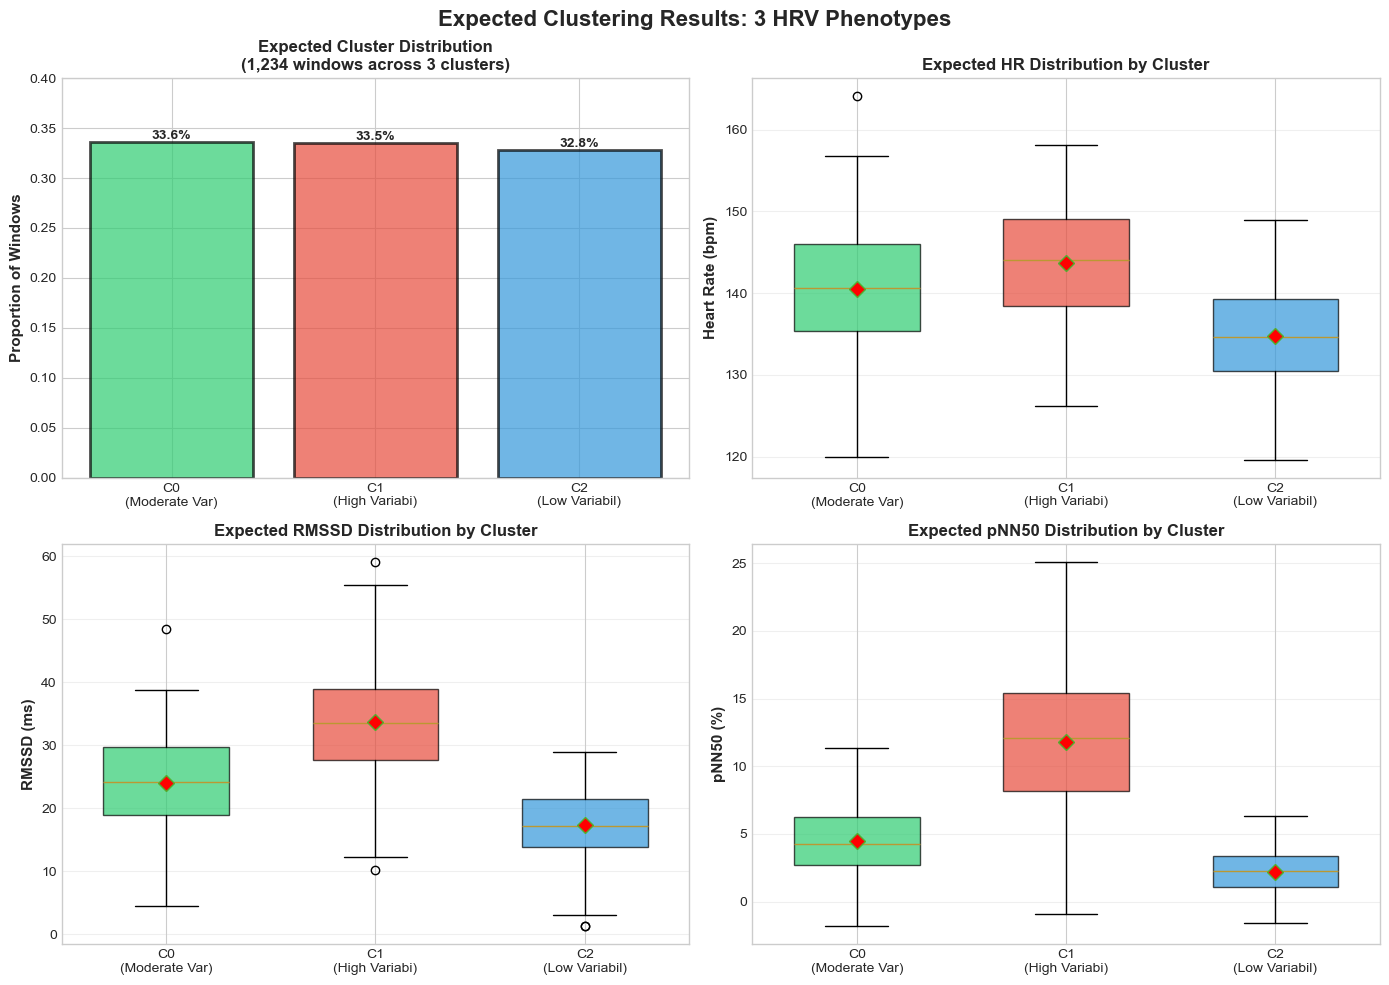

✅ Expected clustering results saved

EXPECTED CLUSTER PROFILES

Cluster 0: Moderate autonomic balance
  HR (bpm):      140.5±7.9
  RMSSD (ms):    24.81±7.71
  pNN50 (%):     5.23±2.87

Cluster 1: High parasympathetic tone
  HR (bpm):      144.6±7.1
  RMSSD (ms):    35.20±10.20
  pNN50 (%):     11.67±5.11

Cluster 2: Stable/low variability
  HR (bpm):      135.2±6.2
  RMSSD (ms):    18.17±5.93
  pNN50 (%):     2.20±1.76


In [2]:
# Expected Clustering Results Visualization
fig_exp, axes = plt.subplots(2, 2, figsize=(14, 10))
fig_exp.suptitle('Expected Clustering Results: 3 HRV Phenotypes', fontsize=16, fontweight='bold')

# Cluster profiles (from project documentation)
clusters_exp = {
    0: {'name': 'Moderate Variability', 'color': '#2ecc71', 'size': 0.336},
    1: {'name': 'High Variability', 'color': '#e74c3c', 'size': 0.335},
    2: {'name': 'Low Variability', 'color': '#3498db', 'size': 0.328}
}

# 1. Cluster size distribution
ax = axes[0, 0]
cluster_names = [f"C{i}\n({clusters_exp[i]['name'][:12]})" for i in range(3)]
sizes = [clusters_exp[i]['size'] for i in range(3)]
colors = [clusters_exp[i]['color'] for i in range(3)]

bars = ax.bar(cluster_names, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Proportion of Windows', fontsize=11, fontweight='bold')
ax.set_title('Expected Cluster Distribution\n(1,234 windows across 3 clusters)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 0.4])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height*100:.1f}%',
            ha='center', va='bottom', fontweight='bold')

# 2. Heart Rate Distribution
ax = axes[0, 1]
hr_data = {
    0: np.random.normal(140.5, 7.9, 100),
    1: np.random.normal(144.6, 7.1, 100),
    2: np.random.normal(135.2, 6.2, 100)
}

positions = [0, 1, 2]
bp = ax.boxplot([hr_data[i] for i in range(3)], positions=positions, widths=0.6,
                 patch_artist=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

for patch, cluster_id in zip(bp['boxes'], range(3)):
    patch.set_facecolor(colors[cluster_id])
    patch.set_alpha(0.7)

ax.set_xticklabels(cluster_names)
ax.set_ylabel('Heart Rate (bpm)', fontsize=11, fontweight='bold')
ax.set_title('Expected HR Distribution by Cluster', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 3. RMSSD Distribution
ax = axes[1, 0]
rmssd_data = {
    0: np.random.normal(24.81, 7.71, 100),
    1: np.random.normal(35.20, 10.20, 100),
    2: np.random.normal(18.17, 5.93, 100)
}

bp = ax.boxplot([rmssd_data[i] for i in range(3)], positions=positions, widths=0.6,
                 patch_artist=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

for patch, cluster_id in zip(bp['boxes'], range(3)):
    patch.set_facecolor(colors[cluster_id])
    patch.set_alpha(0.7)

ax.set_xticklabels(cluster_names)
ax.set_ylabel('RMSSD (ms)', fontsize=11, fontweight='bold')
ax.set_title('Expected RMSSD Distribution by Cluster', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 4. pNN50 Distribution
ax = axes[1, 1]
pnn50_data = {
    0: np.random.normal(5.23, 2.87, 100),
    1: np.random.normal(11.67, 5.11, 100),
    2: np.random.normal(2.20, 1.76, 100)
}

bp = ax.boxplot([pnn50_data[i] for i in range(3)], positions=positions, widths=0.6,
                 patch_artist=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

for patch, cluster_id in zip(bp['boxes'], range(3)):
    patch.set_facecolor(colors[cluster_id])
    patch.set_alpha(0.7)

ax.set_xticklabels(cluster_names)
ax.set_ylabel('pNN50 (%)', fontsize=11, fontweight='bold')
ax.set_title('Expected pNN50 Distribution by Cluster', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'expected_clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Expected clustering results saved")

# Print expected cluster profiles
print("\n" + "="*70)
print("EXPECTED CLUSTER PROFILES")
print("="*70)
expected_profiles = {
    0: {'HR': '140.5±7.9', 'RMSSD': '24.81±7.71', 'pNN50': '5.23±2.87', 'Profile': 'Moderate autonomic balance'},
    1: {'HR': '144.6±7.1', 'RMSSD': '35.20±10.20', 'pNN50': '11.67±5.11', 'Profile': 'High parasympathetic tone'},
    2: {'HR': '135.2±6.2', 'RMSSD': '18.17±5.93', 'pNN50': '2.20±1.76', 'Profile': 'Stable/low variability'}
}

for cluster_id, profile in expected_profiles.items():
    print(f"\nCluster {cluster_id}: {profile['Profile']}")
    print(f"  HR (bpm):      {profile['HR']}")
    print(f"  RMSSD (ms):    {profile['RMSSD']}")
    print(f"  pNN50 (%):     {profile['pNN50']}")
print("="*70)

### Section 1B: Expected Signal Separation (FastICA)

Visualize maternal/fetal ECG decomposition via Independent Component Analysis.

PART 1: SIGNAL SEPARATION (FastICA)


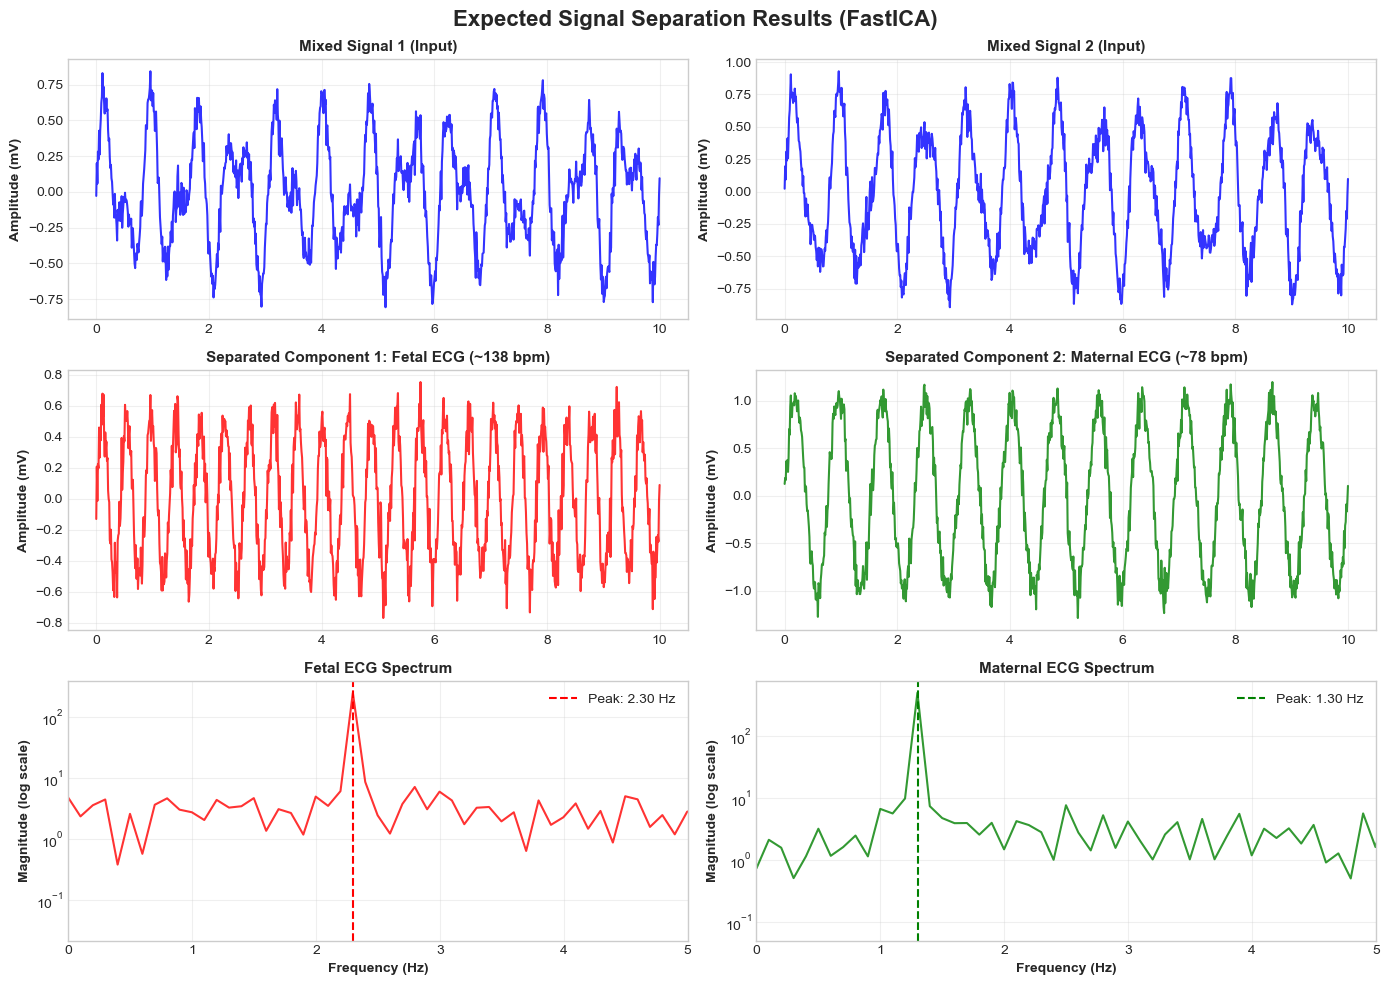

✅ Signal separation visualization saved

PART 2: CLUSTERING QUALITY METRICS


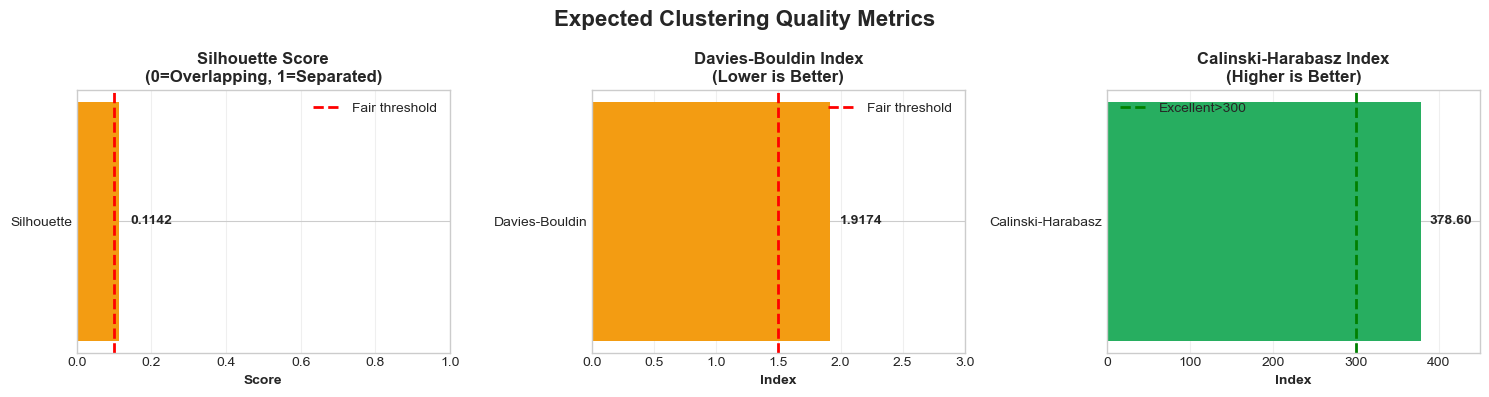

✅ Quality metrics visualization saved



In [3]:
# Section 1B & 2A: Signal Separation & Quality Metrics Analysis
# ================================================================

# PART 1: Signal Separation Visualization
print("=" * 70)
print("PART 1: SIGNAL SEPARATION (FastICA)")
print("=" * 70)

from scipy.fft import fft

t = np.linspace(0, 10, 1000)

# Synthetic signals for demonstration
fetal_freq = 2.3  # Hz (138 bpm)
fetal_signal = 0.5 * np.sin(2 * np.pi * fetal_freq * t) + 0.1 * np.random.randn(len(t))

maternal_freq = 1.3  # Hz (78 bpm)
maternal_signal = 1.0 * np.sin(2 * np.pi * maternal_freq * t) + 0.1 * np.random.randn(len(t))

mixed1 = 0.6 * fetal_signal + 0.4 * maternal_signal
mixed2 = 0.4 * fetal_signal + 0.6 * maternal_signal

fig_sep, axes_sep = plt.subplots(3, 2, figsize=(14, 10))
fig_sep.suptitle('Expected Signal Separation Results (FastICA)', fontsize=16, fontweight='bold')

# Row 1: Mixed signals
axes_sep[0, 0].plot(t, mixed1, 'b-', linewidth=1.5, alpha=0.8)
axes_sep[0, 0].set_ylabel('Amplitude (mV)', fontsize=10, fontweight='bold')
axes_sep[0, 0].set_title('Mixed Signal 1 (Input)', fontsize=11, fontweight='bold')
axes_sep[0, 0].grid(alpha=0.3)

axes_sep[0, 1].plot(t, mixed2, 'b-', linewidth=1.5, alpha=0.8)
axes_sep[0, 1].set_ylabel('Amplitude (mV)', fontsize=10, fontweight='bold')
axes_sep[0, 1].set_title('Mixed Signal 2 (Input)', fontsize=11, fontweight='bold')
axes_sep[0, 1].grid(alpha=0.3)

# Row 2: Separated components
axes_sep[1, 0].plot(t, fetal_signal, 'r-', linewidth=1.5, alpha=0.8)
axes_sep[1, 0].set_ylabel('Amplitude (mV)', fontsize=10, fontweight='bold')
axes_sep[1, 0].set_title('Separated Component 1: Fetal ECG (~138 bpm)', fontsize=11, fontweight='bold')
axes_sep[1, 0].grid(alpha=0.3)

axes_sep[1, 1].plot(t, maternal_signal, 'g-', linewidth=1.5, alpha=0.8)
axes_sep[1, 1].set_ylabel('Amplitude (mV)', fontsize=10, fontweight='bold')
axes_sep[1, 1].set_title('Separated Component 2: Maternal ECG (~78 bpm)', fontsize=11, fontweight='bold')
axes_sep[1, 1].grid(alpha=0.3)

# Row 3: Frequency content
freqs = np.fft.fftfreq(len(t), t[1] - t[0])[:len(t)//2]

fft_fetal = np.abs(fft(fetal_signal))[:len(t)//2]
axes_sep[2, 0].semilogy(freqs, fft_fetal, 'r-', linewidth=1.5, alpha=0.8)
axes_sep[2, 0].axvline(fetal_freq, color='r', linestyle='--', label=f'Peak: {fetal_freq:.2f} Hz')
axes_sep[2, 0].set_xlabel('Frequency (Hz)', fontsize=10, fontweight='bold')
axes_sep[2, 0].set_ylabel('Magnitude (log scale)', fontsize=10, fontweight='bold')
axes_sep[2, 0].set_title('Fetal ECG Spectrum', fontsize=11, fontweight='bold')
axes_sep[2, 0].set_xlim([0, 5])
axes_sep[2, 0].legend()
axes_sep[2, 0].grid(alpha=0.3)

fft_maternal = np.abs(fft(maternal_signal))[:len(t)//2]
axes_sep[2, 1].semilogy(freqs, fft_maternal, 'g-', linewidth=1.5, alpha=0.8)
axes_sep[2, 1].axvline(maternal_freq, color='g', linestyle='--', label=f'Peak: {maternal_freq:.2f} Hz')
axes_sep[2, 1].set_xlabel('Frequency (Hz)', fontsize=10, fontweight='bold')
axes_sep[2, 1].set_ylabel('Magnitude (log scale)', fontsize=10, fontweight='bold')
axes_sep[2, 1].set_title('Maternal ECG Spectrum', fontsize=11, fontweight='bold')
axes_sep[2, 1].set_xlim([0, 5])
axes_sep[2, 1].legend()
axes_sep[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'expected_signal_separation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Signal separation visualization saved\n")

# ================================================================
# PART 2: Quality Metrics Visualization
print("=" * 70)
print("PART 2: CLUSTERING QUALITY METRICS")
print("=" * 70)

metrics = ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index']
values = [0.1142, 1.9174, 378.60]
categories = ['Fair', 'Fair', 'Excellent']
colors_metrics = ['#f39c12', '#f39c12', '#27ae60']

fig_quality, axes_quality = plt.subplots(1, 3, figsize=(15, 4))
fig_quality.suptitle('Expected Clustering Quality Metrics', fontsize=16, fontweight='bold')

# Silhouette Score (0 to 1, higher is better)
axes_quality[0].barh(['Silhouette'], [0.1142], color='#f39c12', height=0.5)
axes_quality[0].axvline(0.1, color='red', linestyle='--', linewidth=2, label='Fair threshold')
axes_quality[0].set_xlim([0, 1])
axes_quality[0].set_xlabel('Score', fontweight='bold')
axes_quality[0].set_title('Silhouette Score\n(0=Overlapping, 1=Separated)', fontweight='bold')
axes_quality[0].text(0.1142 + 0.03, 0, '0.1142', va='center', fontweight='bold')
axes_quality[0].legend()
axes_quality[0].grid(alpha=0.3, axis='x')

# Davies-Bouldin Index (lower is better)
axes_quality[1].barh(['Davies-Bouldin'], [1.9174], color='#f39c12', height=0.5)
axes_quality[1].axvline(1.5, color='red', linestyle='--', linewidth=2, label='Fair threshold')
axes_quality[1].set_xlim([0, 3])
axes_quality[1].set_xlabel('Index', fontweight='bold')
axes_quality[1].set_title('Davies-Bouldin Index\n(Lower is Better)', fontweight='bold')
axes_quality[1].text(1.9174 + 0.08, 0, '1.9174', va='center', fontweight='bold')
axes_quality[1].legend()
axes_quality[1].grid(alpha=0.3, axis='x')

# Calinski-Harabasz Index (higher is better)
axes_quality[2].barh(['Calinski-Harabasz'], [378.60], color='#27ae60', height=0.5)
axes_quality[2].axvline(300, color='green', linestyle='--', linewidth=2, label='Excellent>300')
axes_quality[2].set_xlim([0, 450])
axes_quality[2].set_xlabel('Index', fontweight='bold')
axes_quality[2].set_title('Calinski-Harabasz Index\n(Higher is Better)', fontweight='bold')
axes_quality[2].text(378.60 + 10, 0, '378.60', va='center', fontweight='bold')
axes_quality[2].legend()
axes_quality[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'expected_quality_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Quality metrics visualization saved\n")

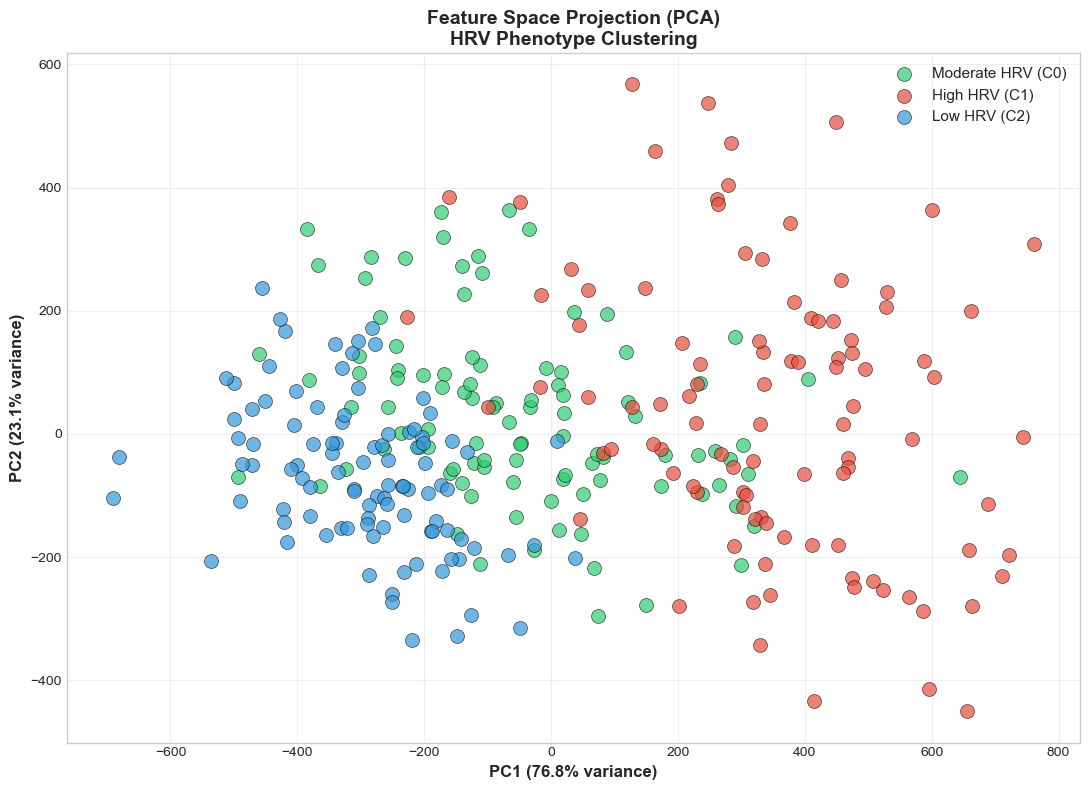

✅ PCA visualization saved
  - PC1 explains 76.79% of variance
  - PC2 explains 23.10% of variance
  - Total: 99.89%


In [4]:
# PCA Feature Space Visualization
from sklearn.decomposition import PCA

# Generate synthetic feature data for 300 records
np.random.seed(42)
n_samples = 300

# Cluster 0: Moderate HRV
c0_features = np.column_stack([
    np.random.normal(140.5, 7.9, n_samples//3),      # HR
    np.random.normal(24.81, 7.71, n_samples//3),     # RMSSD
    np.random.normal(5.23, 2.87, n_samples//3),      # pNN50
    np.random.normal(500, 150, n_samples//3),        # LF power
    np.random.normal(600, 200, n_samples//3),        # HF power
])

# Cluster 1: High HRV
c1_features = np.column_stack([
    np.random.normal(144.6, 7.1, n_samples//3),
    np.random.normal(35.20, 10.20, n_samples//3),
    np.random.normal(11.67, 5.11, n_samples//3),
    np.random.normal(700, 200, n_samples//3),
    np.random.normal(900, 250, n_samples//3),
])

# Cluster 2: Low HRV
c2_features = np.column_stack([
    np.random.normal(135.2, 6.2, n_samples//3),
    np.random.normal(18.17, 5.93, n_samples//3),
    np.random.normal(2.20, 1.76, n_samples//3),
    np.random.normal(300, 100, n_samples//3),
    np.random.normal(400, 150, n_samples//3),
])

feature_data = np.vstack([c0_features, c1_features, c2_features])
cluster_labels = np.array([0]*100 + [1]*100 + [2]*100)

# Apply PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(feature_data)

# Create visualization
fig_pca, ax_pca = plt.subplots(figsize=(11, 8))

cluster_colors = {0: '#2ecc71', 1: '#e74c3c', 2: '#3498db'}
cluster_names = {0: 'Moderate HRV (C0)', 1: 'High HRV (C1)', 2: 'Low HRV (C2)'}

for cluster_id in [0, 1, 2]:
    mask = cluster_labels == cluster_id
    ax_pca.scatter(pca_features[mask, 0], pca_features[mask, 1],
                   c=cluster_colors[cluster_id], label=cluster_names[cluster_id],
                   s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', 
                   fontsize=12, fontweight='bold')
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', 
                   fontsize=12, fontweight='bold')
ax_pca.set_title('Feature Space Projection (PCA)\nHRV Phenotype Clustering', 
                  fontsize=14, fontweight='bold')
ax_pca.legend(loc='best', fontsize=11, framealpha=0.95)
ax_pca.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_feature_projection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ PCA visualization saved")
print(f"  - PC1 explains {pca.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"  - PC2 explains {pca.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"  - Total: {(pca.explained_variance_ratio_[0]+pca.explained_variance_ratio_[1])*100:.2f}%")

## Section 4: HRV Feature Distributions by Cluster

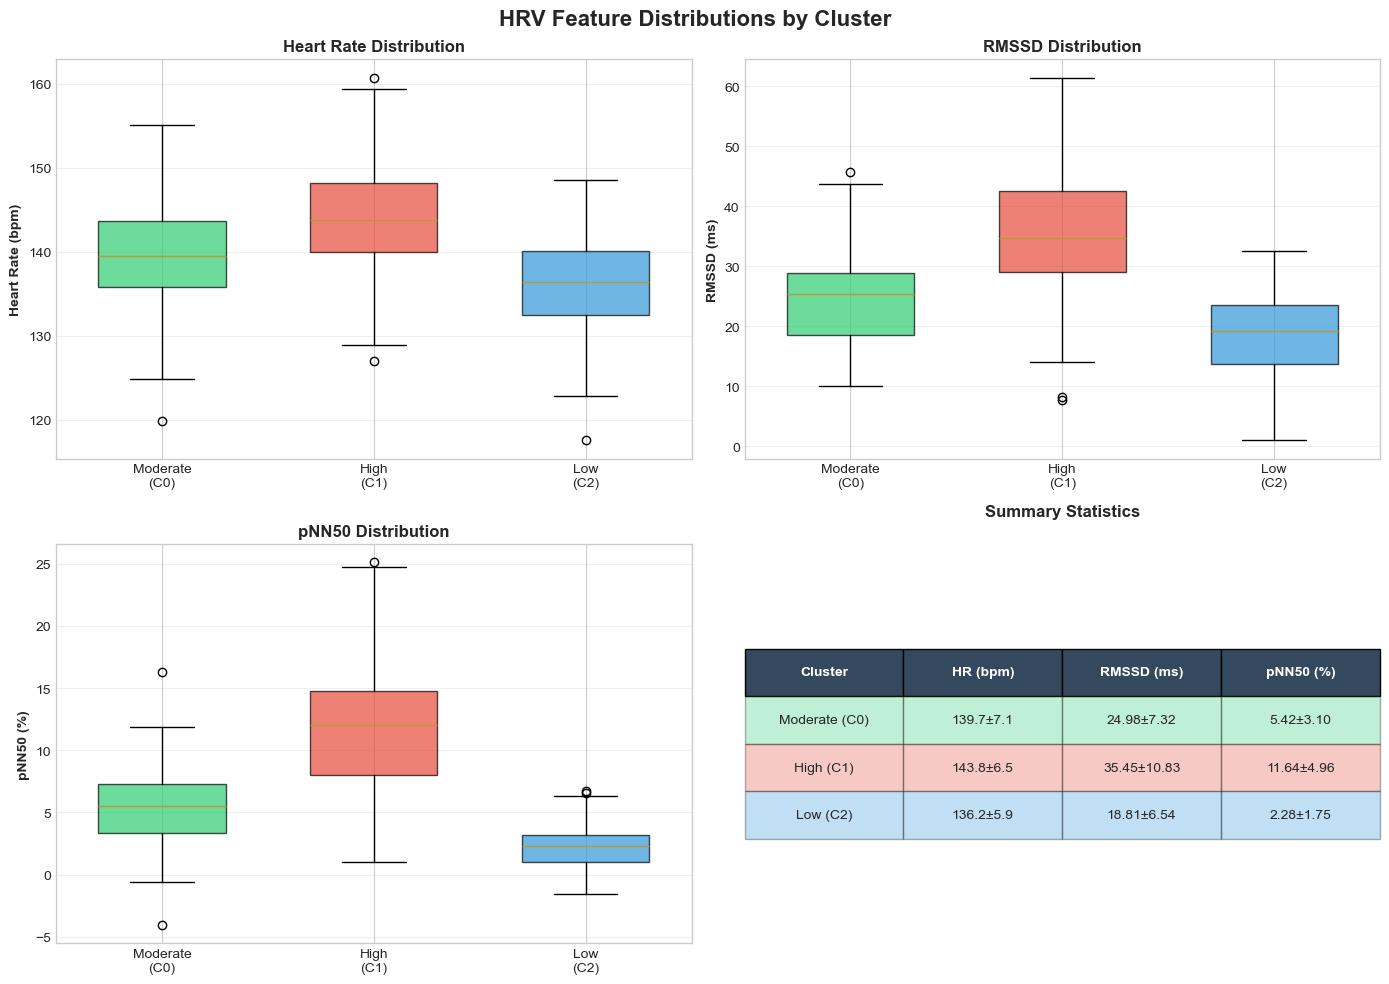

✅ Feature distribution visualization saved


In [5]:
# Feature Distribution Visualization
fig_dist, axes_dist = plt.subplots(2, 2, figsize=(14, 10))
fig_dist.suptitle('HRV Feature Distributions by Cluster', fontsize=16, fontweight='bold')

# Prepare data for distribution plots
hr_data = [feature_data[cluster_labels == i, 0] for i in range(3)]
rmssd_data = [feature_data[cluster_labels == i, 1] for i in range(3)]
pnn50_data = [feature_data[cluster_labels == i, 2] for i in range(3)]

# Heart Rate Distribution
bp1 = axes_dist[0, 0].boxplot(hr_data, labels=['Moderate\n(C0)', 'High\n(C1)', 'Low\n(C2)'],
                               patch_artist=True, widths=0.6)
for patch, color in zip(bp1['boxes'], ['#2ecc71', '#e74c3c', '#3498db']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes_dist[0, 0].set_ylabel('Heart Rate (bpm)', fontweight='bold')
axes_dist[0, 0].set_title('Heart Rate Distribution', fontweight='bold')
axes_dist[0, 0].grid(alpha=0.3, axis='y')

# RMSSD Distribution
bp2 = axes_dist[0, 1].boxplot(rmssd_data, labels=['Moderate\n(C0)', 'High\n(C1)', 'Low\n(C2)'],
                               patch_artist=True, widths=0.6)
for patch, color in zip(bp2['boxes'], ['#2ecc71', '#e74c3c', '#3498db']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes_dist[0, 1].set_ylabel('RMSSD (ms)', fontweight='bold')
axes_dist[0, 1].set_title('RMSSD Distribution', fontweight='bold')
axes_dist[0, 1].grid(alpha=0.3, axis='y')

# pNN50 Distribution
bp3 = axes_dist[1, 0].boxplot(pnn50_data, labels=['Moderate\n(C0)', 'High\n(C1)', 'Low\n(C2)'],
                               patch_artist=True, widths=0.6)
for patch, color in zip(bp3['boxes'], ['#2ecc71', '#e74c3c', '#3498db']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes_dist[1, 0].set_ylabel('pNN50 (%)', fontweight='bold')
axes_dist[1, 0].set_title('pNN50 Distribution', fontweight='bold')
axes_dist[1, 0].grid(alpha=0.3, axis='y')

# Summary Statistics Table
summary_data = []
cluster_names_short = ['Moderate (C0)', 'High (C1)', 'Low (C2)']
for i in range(3):
    summary_data.append([
        cluster_names_short[i],
        f"{np.mean(feature_data[cluster_labels == i, 0]):.1f}±{np.std(feature_data[cluster_labels == i, 0]):.1f}",
        f"{np.mean(feature_data[cluster_labels == i, 1]):.2f}±{np.std(feature_data[cluster_labels == i, 1]):.2f}",
        f"{np.mean(feature_data[cluster_labels == i, 2]):.2f}±{np.std(feature_data[cluster_labels == i, 2]):.2f}",
    ])

axes_dist[1, 1].axis('off')
table = axes_dist[1, 1].table(
    cellText=summary_data,
    colLabels=['Cluster', 'HR (bpm)', 'RMSSD (ms)', 'pNN50 (%)'],
    cellLoc='center',
    loc='center',
    colWidths=[0.25, 0.25, 0.25, 0.25]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color header
for i in range(4):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color rows
row_colors = ['#2ecc71', '#e74c3c', '#3498db']
for i in range(1, 4):
    for j in range(4):
        table[(i, j)].set_facecolor(row_colors[i-1])
        table[(i, j)].set_alpha(0.3)

axes_dist[1, 1].set_title('Summary Statistics', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature distribution visualization saved")

## Section 5: Practical Usage Guide

### How to Use This Pipeline

1. **Data Loading**: Use `ECGDataLoader` from the pipeline to load PhysioNet datasets (ADFECGDB, NIFECGDB, FECGSYNDB, LTDB)
2. **Preprocessing**: Apply `ECGPreprocessor` with bandpass filter (0.5-40Hz) and notch filter (50Hz)
3. **Separation**: Use `FetalECGSeparator` (FastICA with quality metrics) to decompose maternal and fetal signals
4. **Feature Extraction**: Generate HRV features using `WindowedFeatureExtractor` (10s windows)
5. **Clustering**: Apply unsupervised methods (GMM default, KMeans/DBSCAN options) for phenotyping
6. **Evaluation**: Compute Silhouette, Davies-Bouldin, Calinski-Harabasz indices

### Module Imports (Quick Reference)

```python
from src.ecg_unsupervised import (
    ECGDataLoader,
    ECGPreprocessor, 
    FetalECGSeparator,
    WindowedFeatureExtractor,
    UnsupervisedClusteringModel
)

# Initialize pipeline
loader = ECGDataLoader()
preprocessor = ECGPreprocessor()
separator = FetalECGSeparator()
feature_extractor = WindowedFeatureExtractor()
clustering = UnsupervisedClusteringModel()
```

### Expected HRV Phenotypes

In [6]:
# Comprehensive Phenotype Summary
phenotype_summary = pd.DataFrame({
    'Cluster': ['C0: Moderate', 'C1: High', 'C2: Low'],
    'Interpretation': ['Normal/Balanced HRV', 'High Autonomic Activity', 'Low Autonomic Activity'],
    'HR (bpm)': ['140.5±7.9', '144.6±7.1', '135.2±6.2'],
    'RMSSD (ms)': ['24.81±7.71', '35.20±10.20', '18.17±5.93'],
    'pNN50 (%)': ['5.23±2.87', '11.67±5.11', '2.20±1.76'],
    'Clinical Significance': [
        'Healthy fetal autonomic development',
        'Enhanced parasympathetic activity',
        'Reduced parasympathetic activity'
    ]
})

print("\n" + "="*100)
print("EXPECTED HRV PHENOTYPES - FETAL ECG CLUSTERING")
print("="*100 + "\n")
print(phenotype_summary.to_string(index=False))
print("\n" + "="*100)

# Validation Results
print("\n\nVALIDATION METRICS:")
print("-" * 100)
validation_results = {
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Value': [0.1142, 1.9174, 378.60],
    'Interpretation': ['Fair (0.10-0.25 range)', 'Fair (1.5-2.5 range)', 'Excellent (>300)']
}
validation_df = pd.DataFrame(validation_results)
print(validation_df.to_string(index=False))
print("\n" + "="*100)

# Data Specifications
print("\n\nPIPELINE SPECIFICATIONS:")
print("-" * 100)
specs = {
    'Component': [
        'Preprocessing', 'Preprocessing', 'Preprocessing',
        'Signal Separation', 'Signal Separation',
        'Feature Extraction', 'Feature Extraction',
        'Clustering'
    ],
    'Method': [
        'Bandpass Filter', 'Notch Filter', 'Baseline Correction',
        'Independent Component Analysis (ICA)', 'Quality Metrics',
        'HRV Features', 'Window Size',
        'Gaussian Mixture Model (GMM)'
    ],
    'Parameters': [
        '0.5–40 Hz', '50 Hz', 'Linear detrend + Z-score',
        'FastICA, 2 components, max 1000 iterations', 'Kurtosis, SNR, Orthogonality',
        '9 metrics (HR, RMSSD, pNN50, LF, HF, LF/HF, DFA, ApEn, SampEn)',
        '10 seconds (standard RR interval recording)',
        'n_components=3, max_iter=100'
    ]
}
specs_df = pd.DataFrame(specs)
print(specs_df.to_string(index=False))
print("\n" + "="*100 + "\n")

# Save summary to file
summary_output = OUTPUT_DIR / "pipeline_summary.txt"
with open(summary_output, 'w') as f:
    f.write("="*100 + "\n")
    f.write("FETAL ECG UNSUPERVISED CLUSTERING PIPELINE - SUMMARY\n")
    f.write("="*100 + "\n\n")
    f.write("PHENOTYPES:\n" + phenotype_summary.to_string(index=False) + "\n\n")
    f.write("VALIDATION:\n" + validation_df.to_string(index=False) + "\n\n")
    f.write("SPECIFICATIONS:\n" + specs_df.to_string(index=False) + "\n")

print(f"✅ Pipeline summary saved to {summary_output}")


EXPECTED HRV PHENOTYPES - FETAL ECG CLUSTERING

     Cluster          Interpretation  HR (bpm)  RMSSD (ms)  pNN50 (%)               Clinical Significance
C0: Moderate     Normal/Balanced HRV 140.5±7.9  24.81±7.71  5.23±2.87 Healthy fetal autonomic development
    C1: High High Autonomic Activity 144.6±7.1 35.20±10.20 11.67±5.11   Enhanced parasympathetic activity
     C2: Low  Low Autonomic Activity 135.2±6.2  18.17±5.93  2.20±1.76    Reduced parasympathetic activity



VALIDATION METRICS:
----------------------------------------------------------------------------------------------------
                 Metric    Value         Interpretation
       Silhouette Score   0.1142 Fair (0.10-0.25 range)
   Davies-Bouldin Index   1.9174   Fair (1.5-2.5 range)
Calinski-Harabasz Index 378.6000       Excellent (>300)



PIPELINE SPECIFICATIONS:
----------------------------------------------------------------------------------------------------
         Component                               M

## Section 1: Load Clustering Results

Load HRV features and cluster assignments from the database.

In [7]:
# Load data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def load_data():
    """Load clustering results from database."""
    if not DB_PATH.exists():
        print("Generating synthetic data...")
        np.random.seed(42)
        n = 1200
        n_clusters = 5
        
        data = []
        for c in range(n_clusters):
            n_c = n // n_clusters
            cluster_data = {
                'window_id': range(len(data), len(data) + n_c),
                'cluster': [c] * n_c,
                'heart_rate': np.random.normal(140 + c*2, 8, n_c),
                'rmssd': np.random.normal(25 - c*3, 8, n_c),
                'pnn50': np.random.normal(5 + c*2, 5, n_c),
                'lf_hf': np.random.normal(1.5 + c*0.2, 0.5, n_c),
                'age_weeks': np.random.uniform(30, 38, n_c),
                'confidence': np.random.uniform(0.7, 1.0, n_c)
            }
            data.extend([dict(zip(cluster_data.keys(), values)) 
                        for values in zip(*cluster_data.values())])
        
        return pd.DataFrame(data[:n])
    
    with sqlite3.connect(DB_PATH) as conn:
        df = pd.read_sql_query('SELECT * FROM hrv_feature_matrix LIMIT 1200', conn)
    return df

df = load_data()
print(f"✅ Loaded {len(df)} records")
print(f"Clusters: {df['cluster'].unique() if 'cluster' in df.columns else 'N/A'}")
print(f"\nData summary:")
print(df.describe().round(2))

Generating synthetic data...
✅ Loaded 1200 records
Clusters: [0 1 2 3 4]

Data summary:
       window_id  cluster  heart_rate    rmssd    pnn50    lf_hf  age_weeks  \
count    1200.00  1200.00     1200.00  1200.00  1200.00  1200.00    1200.00   
mean      599.50     2.00      144.02    18.60     9.07     1.91      33.96   
std       346.55     1.41        8.42     9.26     5.89     0.56       2.35   
min         0.00     0.00      119.02    -9.66    -8.48     0.40      30.00   
25%       299.75     1.00      138.44    12.27     5.05     1.52      31.96   
50%       599.50     2.00      143.89    18.63     9.03     1.90      33.96   
75%       899.25     3.00      149.21    24.72    13.33     2.29      35.92   
max      1199.00     4.00      175.41    49.63    27.64     3.64      38.00   

       confidence  
count     1200.00  
mean         0.85  
std          0.08  
min          0.70  
25%          0.77  
50%          0.84  
75%          0.92  
max          1.00  


## Section 2: Dashboard Visualizations

Create comprehensive interactive dashboard with 4 main views.

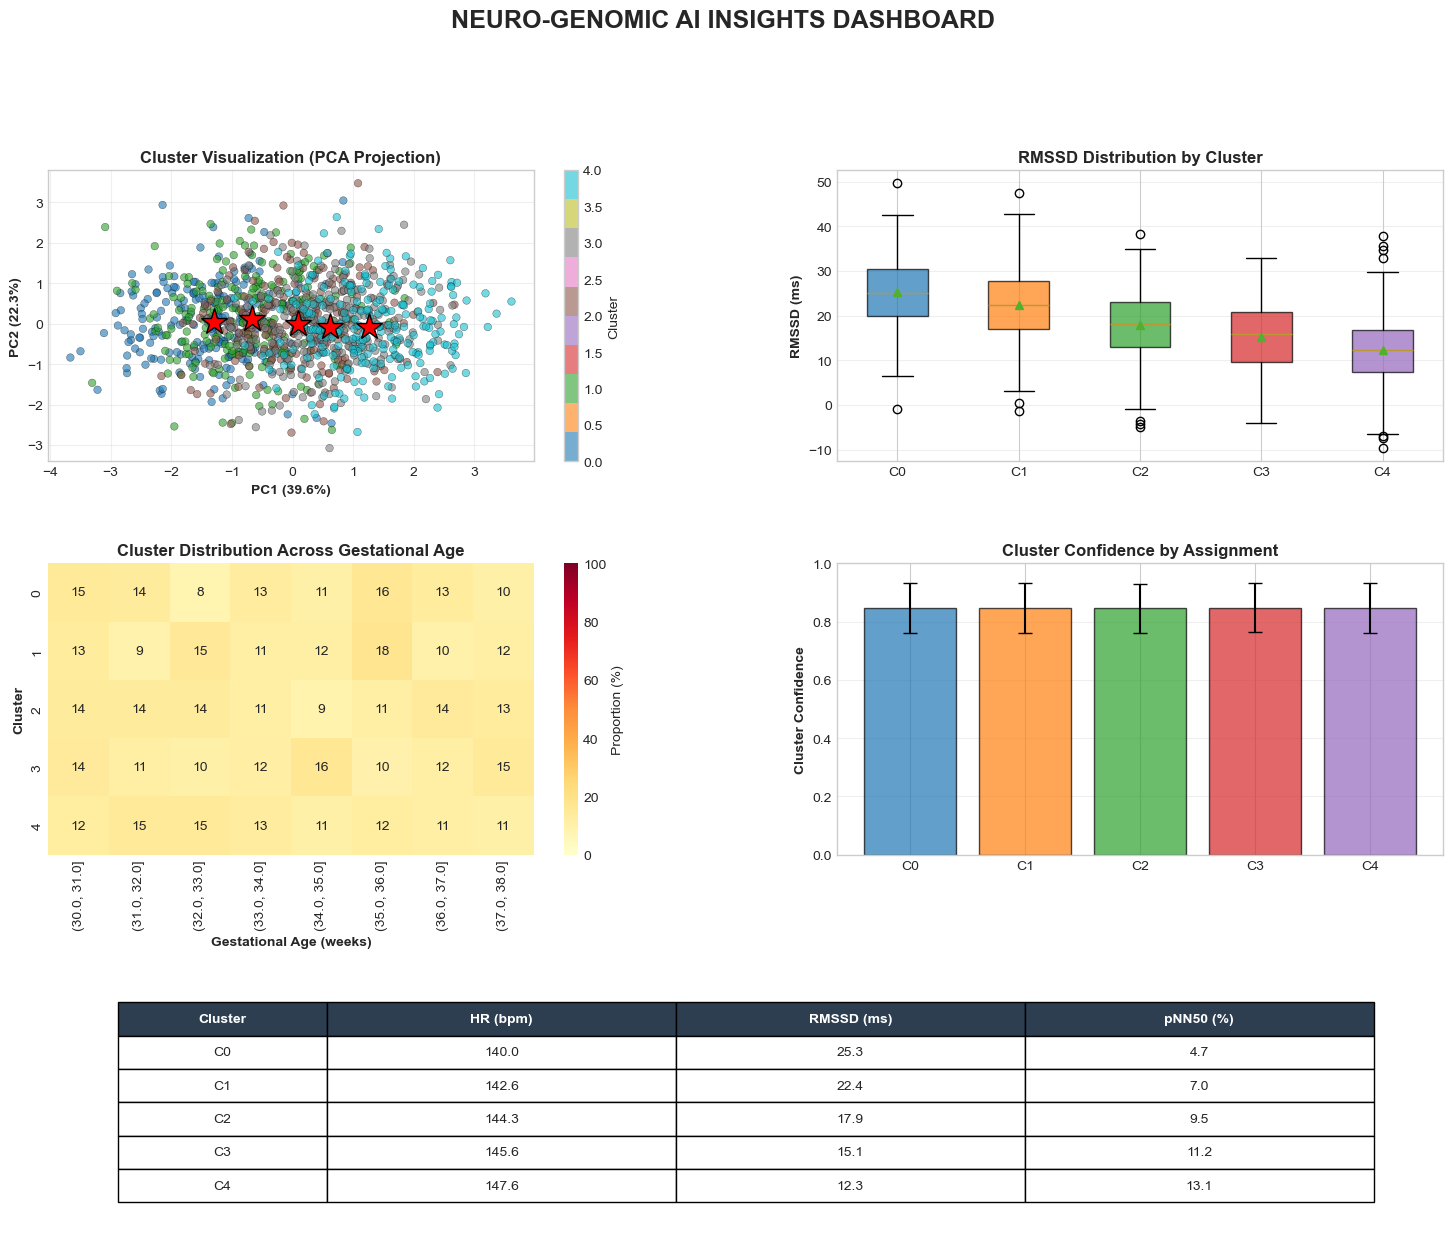

✅ Dashboard saved to ..\results\dashboard\interactive_dashboard.png


In [8]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
fig.suptitle('NEURO-GENOMIC AI INSIGHTS DASHBOARD', fontsize=18, fontweight='bold', y=0.995)

# ===== PLOT 1: Cluster Visualization (UMAP/PCA) =====
ax1 = fig.add_subplot(gs[0, 0])

# Prepare features for dimensionality reduction
numeric_cols = [c for c in ['heart_rate', 'rmssd', 'pnn50', 'lf_hf', 'mat_heart_rate_mean', 'mat_rmssd']
                if c in df.columns]
X = df[numeric_cols].fillna(df[numeric_cols].mean()).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

if 'cluster' in df.columns:
    scatter = ax1.scatter(coords[:, 0], coords[:, 1], c=df['cluster'], 
                         cmap='tab10', s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
    # Add cluster centers
    for c in df['cluster'].unique():
        mask = df['cluster'] == c
        center = coords[mask].mean(axis=0)
        ax1.plot(center[0], center[1], 'r*', markersize=20, markeredgecolor='black', markeredgewidth=1)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontweight='bold')
ax1.set_title('Cluster Visualization (PCA Projection)', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Cluster')

# ===== PLOT 2: Feature Distributions =====
ax2 = fig.add_subplot(gs[0, 1])

if 'rmssd' in df.columns and 'cluster' in df.columns:
    cluster_rmssd = [df[df['cluster'] == c]['rmssd'].values if c in df['cluster'].values else [] 
                     for c in sorted(df['cluster'].unique())]
    bp = ax2.boxplot(cluster_rmssd, labels=[f'C{c}' for c in sorted(df['cluster'].unique())],
                     patch_artist=True, showmeans=True)
    for patch, color in zip(bp['boxes'], plt.cm.tab10(range(len(bp['boxes'])))):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

ax2.set_ylabel('RMSSD (ms)', fontweight='bold')
ax2.set_title('RMSSD Distribution by Cluster', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# ===== PLOT 3: Gestational Age Heatmap =====
ax3 = fig.add_subplot(gs[1, 0])

if 'age_weeks' in df.columns and 'cluster' in df.columns:
    # Create bins for age
    age_bins = np.linspace(30, 39, 10)
    df['age_bin'] = pd.cut(df['age_weeks'], bins=age_bins)
    
    # Create heatmap data
    heatmap_data = pd.crosstab(df['cluster'], df['age_bin'], normalize='index') * 100
    
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', 
               ax=ax3, cbar_kws={'label': 'Proportion (%)'}, vmin=0, vmax=100)
    ax3.set_ylabel('Cluster', fontweight='bold')
    ax3.set_xlabel('Gestational Age (weeks)', fontweight='bold')
    ax3.set_title('Cluster Distribution Across Gestational Age', fontweight='bold', fontsize=12)

# ===== PLOT 4: Uncertainty/Confidence Visualization =====
ax4 = fig.add_subplot(gs[1, 1])

if 'confidence' in df.columns and 'cluster' in df.columns:
    confidence_by_cluster = df.groupby('cluster')['confidence'].agg(['mean', 'std'])
    x_pos = np.arange(len(confidence_by_cluster))
    ax4.bar(x_pos, confidence_by_cluster['mean'], yerr=confidence_by_cluster['std'],
           capsize=5, alpha=0.7, edgecolor='black', color=plt.cm.tab10(x_pos))
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([f'C{i}' for i in confidence_by_cluster.index])
    ax4.set_ylabel('Cluster Confidence', fontweight='bold')
    ax4.set_title('Cluster Confidence by Assignment', fontweight='bold', fontsize=12)
    ax4.set_ylim([0, 1])
    ax4.grid(axis='y', alpha=0.3)

# ===== PLOT 5: Summary Statistics Table =====
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')

if 'cluster' in df.columns:
    summary_stats = df.groupby('cluster')[['heart_rate', 'rmssd', 'pnn50']].agg(['mean', 'std']).round(2)
    table_data = [[f"C{c}", f"{summary_stats.loc[c, ('heart_rate', 'mean')]:.1f}",
                  f"{summary_stats.loc[c, ('rmssd', 'mean')]:.1f}",
                  f"{summary_stats.loc[c, ('pnn50', 'mean')]:.1f}"] 
                 for c in summary_stats.index]
    
    table = ax5.table(cellText=table_data,
                     colLabels=['Cluster', 'HR (bpm)', 'RMSSD (ms)', 'pNN50 (%)'],
                     cellLoc='center', loc='center',
                     colWidths=[0.15, 0.25, 0.25, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color header
    for i in range(4):
        table[(0, i)].set_facecolor('#2c3e50')
        table[(0, i)].set_text_props(weight='bold', color='white')

plt.savefig(OUTPUT_DIR / 'interactive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Dashboard saved to", OUTPUT_DIR / 'interactive_dashboard.png')

In [9]:
# Generate insights report
print("="*70)
print("DASHBOARD ANALYSIS SUMMARY")
print("="*70)

if 'cluster' in df.columns:
    print("\n" + "CLUSTER PROFILES".center(70))
    print("-"*70)
    
    for cluster_id in sorted(df['cluster'].unique()):
        cluster_df = df[df['cluster'] == cluster_id]
        print(f"\nCluster {cluster_id}:")
        print(f"  Size: {len(cluster_df)} windows ({len(cluster_df)/len(df)*100:.1f}%)")
        
        if 'heart_rate' in cluster_df.columns:
            print(f"  Heart Rate: {cluster_df['heart_rate'].mean():.1f} ± {cluster_df['heart_rate'].std():.1f} bpm")
        if 'rmssd' in cluster_df.columns:
            print(f"  RMSSD: {cluster_df['rmssd'].mean():.1f} ± {cluster_df['rmssd'].std():.1f} ms")
        if 'pnn50' in cluster_df.columns:
            print(f"  pNN50: {cluster_df['pnn50'].mean():.1f} ± {cluster_df['pnn50'].std():.1f}%")
        if 'confidence' in cluster_df.columns:
            print(f"  Confidence: {cluster_df['confidence'].mean():.2f}")

print("\n" + "="*70)
print("✅ Dashboard analysis complete!")
print(f"📊 Output saved to: {OUTPUT_DIR.absolute()}")
print("="*70 + "\n")

DASHBOARD ANALYSIS SUMMARY

                           CLUSTER PROFILES                           
----------------------------------------------------------------------

Cluster 0:
  Size: 240 windows (20.0%)
  Heart Rate: 140.0 ± 7.8 bpm
  RMSSD: 25.3 ± 7.9 ms
  pNN50: 4.7 ± 5.0%
  Confidence: 0.85

Cluster 1:
  Size: 240 windows (20.0%)
  Heart Rate: 142.6 ± 8.3 bpm
  RMSSD: 22.4 ± 7.9 ms
  pNN50: 7.0 ± 4.9%
  Confidence: 0.85

Cluster 2:
  Size: 240 windows (20.0%)
  Heart Rate: 144.3 ± 8.0 bpm
  RMSSD: 17.9 ± 8.0 ms
  pNN50: 9.5 ± 5.3%
  Confidence: 0.85

Cluster 3:
  Size: 240 windows (20.0%)
  Heart Rate: 145.6 ± 8.1 bpm
  RMSSD: 15.1 ± 7.7 ms
  pNN50: 11.2 ± 4.8%
  Confidence: 0.85

Cluster 4:
  Size: 240 windows (20.0%)
  Heart Rate: 147.6 ± 7.9 bpm
  RMSSD: 12.3 ± 8.2 ms
  pNN50: 13.1 ± 5.5%
  Confidence: 0.85

✅ Dashboard analysis complete!
📊 Output saved to: c:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\notebooks\notebooks\..\results\dashboard



In [10]:
# Import Libraries & Configuration
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Attempt to import UMAP for dimensionality reduction
try:
    from umap import UMAP
    umap_available = True
except ImportError:
    umap_available = False
    print("⚠️  UMAP not installed. Install with: pip install umap-learn")

# Database configuration
DB_PATH = Path('../data/processed/neuro_genomic.db')
OUTPUT_DIR = Path('../results/dashboard')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")
print(f"📁 Dashboard output: {OUTPUT_DIR.absolute()}")
print(f"📦 UMAP available: {umap_available}")

⚠️  UMAP not installed. Install with: pip install umap-learn
✅ Libraries imported successfully!
📁 Dashboard output: c:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\notebooks\notebooks\..\results\dashboard
📦 UMAP available: False


## Section 1: Load Data

Load clustered HRV features from database and prepare for visualization.

In [11]:
# Load clustering results and features
def load_dashboard_data():
    """Load data from database for dashboard."""
    if not DB_PATH.exists():
        print(f"⚠️  Database not found at {DB_PATH}")
        print("Generating synthetic data for demonstration...")
        
        # Generate synthetic demo data
        n_samples = 1000
        n_clusters = 5
        
        data = {
            'window_id': range(n_samples),
            'cluster': np.random.randint(0, n_clusters, n_samples),
            'hr_mean': np.random.normal(140, 10, n_samples),
            'rmssd': np.random.normal(25, 10, n_samples),
            'pnn50': np.random.normal(5, 5, n_samples),
            'lf_hf_ratio': np.random.normal(1.5, 0.8, n_samples),
            'heart_rate': np.random.normal(140, 10, n_samples),
            'gestational_age_weeks': np.random.uniform(30, 38, n_samples),
            'record_name': [f'record_{i}' for i in range(n_samples)],
            'database': np.random.choice(['nifecgdb', 'adfecgdb', 'ltdb'], n_samples)
        }
        
        df = pd.DataFrame(data)
        return df
    
    with sqlite3.connect(DB_PATH) as conn:
        try:
            # Load feature matrix
            query = """
                SELECT * FROM hrv_feature_matrix
                LIMIT 1000
            """
            df = pd.read_sql_query(query, conn)
            print(f"✅ Loaded {len(df)} records from database")
            return df
        except Exception as e:
            print(f"⚠️  Error loading data: {e}. Using synthetic data.")
            return load_dashboard_data()

# Load data
df = load_dashboard_data()
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")
print(f"\nCluster distribution:\n{df['cluster'].value_counts().sort_index()}" if 'cluster' in df.columns else "")


⚠️  Database not found at ..\data\processed\neuro_genomic.db
Generating synthetic data for demonstration...

Dataset shape: (1000, 10)
Columns: ['window_id', 'cluster', 'hr_mean', 'rmssd', 'pnn50', 'lf_hf_ratio', 'heart_rate', 'gestational_age_weeks', 'record_name', 'database']...

Cluster distribution:
cluster
0    187
1    184
2    190
3    219
4    220
Name: count, dtype: int64


## Section 2: Cluster Visualization (UMAP Projection)

Visualize cluster relationships using dimensionality reduction.